# Set up

In [1]:
#importing packages
#packages for directory and file handling
import os
import glob
import json

#packages for time handling
import time as pytime
from sqlite3 import Date
import datetime

#packages for flow cytometry data handling
import FlowCal

#packages for data handling
import pprint
import re
from datetime import date
import pandas as pd
import numpy as np
from numpy.polynomial.polynomial import Polynomial
from pandas.api.types import CategoricalDtype

#packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

from scipy.stats import gaussian_kde
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [2]:
#fontsize =7
def custom_theme_7pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 7
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 7
    plt.rcParams['legend.title_fontsize'] = 7
    plt.rcParams['axes.labelsize'] = 7
    plt.rcParams['axes.titlesize'] = 7
    plt.rcParams['axes.grid'] = False

    #additionas to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42 


#fontsize = 6
def custom_theme_6pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 6
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 6
    plt.rcParams['legend.title_fontsize'] = 6
    plt.rcParams['axes.labelsize'] = 6
    plt.rcParams['axes.titlesize'] = 6
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42


#fontsize =5
def custom_theme_5pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 5
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 5
    plt.rcParams['legend.title_fontsize'] = 5
    plt.rcParams['axes.labelsize'] = 5
    plt.rcParams['axes.titlesize'] = 5
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

In [ ]:
#adjust colormap for density coloring
def modify_colormap_alpha(cmap, alpha=1.0):
    colors = cmap(np.linspace(0, 1, cmap.N))
    colors[:, -1] = alpha  # Set the alpha channel
    return LinearSegmentedColormap.from_list(f"{cmap.name}_opaque", colors)

#load and modify colormap
with open("../../color_palettes/batlow_colors.txt") as f:
    bilbao_colors = [line.strip() for line in f]
bilbao_cmap = LinearSegmentedColormap.from_list("bilbao", bilbao_colors)
opaque_bilbao_cmap = modify_colormap_alpha(bilbao_cmap, alpha=1.0)

In [5]:
#get all subdirs in fcs_files (corresponding to experiments)
os.getcwd()
output = os.listdir('fcs_files')
print(sorted(output))

#check filenames in a dir
fcs_output = glob.glob('fcs_files/ALS_250513_KOLF_regional_spec/*.fcs')
sorted(fcs_output)[:5]

['.DS_Store', 'ALS_250513_KOLF_regional_spec']


['fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_APC Stained Control.fcs',
 'fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_DAPI Stained Control.fcs',
 'fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_Unstained Control.fcs',
 'fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO APCDD1.fcs',
 'fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO DAPI.fcs']

In [6]:
#make a list of all the folders
folder_names = ['ALS_250513_KOLF_regional_spec']

#make a dictionary (with the folders as keys and the fcs files as value)
sorted_files = {}

#iterate over the folder names to sort the .fcs files in each folder
for folder in folder_names: 
    files = glob.glob(f'fcs_files/{folder}/*.fcs')
    sorted_files[folder] = sorted(files)

#inspect the results of the iteration (uncomment to inspect)
pprint.pprint(sorted_files)

{'ALS_250513_KOLF_regional_spec': ['fcs_files/ALS_250513_KOLF_regional_spec/Compensation '
                                   'Controls_APC Stained Control.fcs',
                                   'fcs_files/ALS_250513_KOLF_regional_spec/Compensation '
                                   'Controls_DAPI Stained Control.fcs',
                                   'fcs_files/ALS_250513_KOLF_regional_spec/Compensation '
                                   'Controls_Unstained Control.fcs',
                                   'fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO '
                                   'APCDD1.fcs',
                                   'fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO '
                                   'DAPI.fcs',
                                   'fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_Fully '
                                   'unstained.fcs',
                                   'fcs_files/ALS_250513_KOLF_regional_spec/Fully '
                 

In [ ]:
#check import
imported_files = {}
counter = 0  # to limit the number of rows printed
for folder in sorted_files:
    for filename in sorted_files[folder]:
        if counter == 10:
            break
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[filename] = fcs_data
            #print(f"Channels in file {filename}: {fcs_data.channels}")
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")
        counter += 1

#inspect the results of the iteration (uncomment to inspect)
#pprint.pprint(imported_files)

#import all files in the dictionary and save as new dictionary
imported_files = {}
for folder in sorted_files:
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#inspect shape of imported fcs files
keys_shapes = []
for key, value in imported_files.items():
    keys_shapes.append(f"{key}: {value.shape}")

#make output more readable (uncomment to inspect)
#pp = pprint.PrettyPrinter(indent=4)
#pp.pprint(keys_shapes)

In [ ]:
#make a dictionary (with the folders as keys and the fcs files as value)
sorted_files = {}

#iterate over the folder names to sort the .fcs files in each folder
for folder in folder_names: 
    files = glob.glob(f'fcs_files/{folder}/*.fcs')
    sorted_files[folder] = sorted(files)

#import all files in the dictionary and save as new dictionary
imported_files = {}

#(flat) dictionary
for folder in sorted_files:
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}. Skipping file.")

#inspect channels of the imported fcs files
for filename, fcs_data in imported_files.items():
    print(f"Channels in file {filename}: {fcs_data.channels}")
    print(f"Shape of file {filename}: {fcs_data.shape}")

Channels in file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_APC Stained Control.fcs: ('Time', 'FSC-A', 'FSC-W', 'FSC-H', 'SSC-A', 'SSC-W', 'SSC-H', 'DAPI-A', 'APC-A')
Shape of file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_APC Stained Control.fcs: (10000, 9)
Channels in file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_DAPI Stained Control.fcs: ('Time', 'FSC-A', 'FSC-W', 'FSC-H', 'SSC-A', 'SSC-W', 'SSC-H', 'DAPI-A', 'APC-A')
Shape of file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_DAPI Stained Control.fcs: (5000, 9)
Channels in file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_Unstained Control.fcs: ('Time', 'FSC-A', 'FSC-W', 'FSC-H', 'SSC-A', 'SSC-W', 'SSC-H', 'DAPI-A', 'APC-A')
Shape of file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_Unstained Control.fcs: (5000, 9)
Channels in file fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO APCDD1.fcs: ('Time', 'FSC-A', 'FSC-W', 'FSC

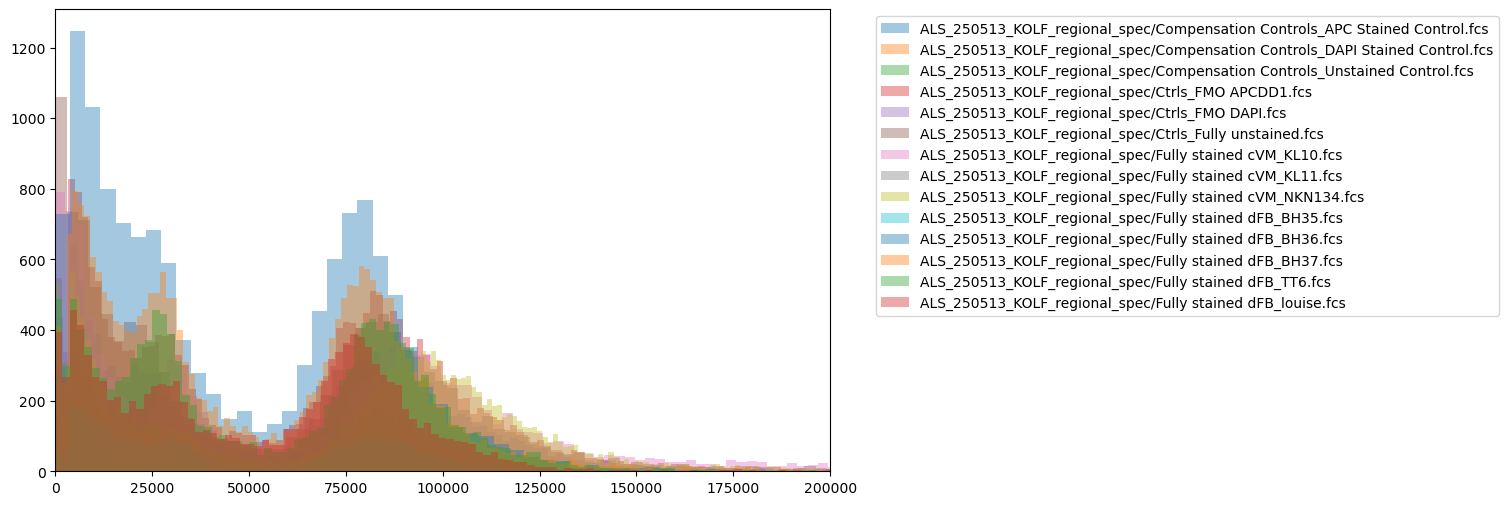

In [9]:
plt.figure(figsize=(10, 6)) # make the figure wider
for i, (filename, file) in enumerate(imported_files.items()):
    #remove the sample with too many events
    if '240508/Fully stained' in filename:
        continue
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    plt.hist(file[:, 'FSC-A'], bins=400, alpha=0.4, 
                label=f'{folder_name}/{os.path.basename(filename)}')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 2e5)
#plt.ylim(0, 1250)
plt.show()

## Plot to determine gating

In [10]:
#print the names of the files
for filename in imported_files.keys():
    print(filename)

fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_APC Stained Control.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_DAPI Stained Control.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_Unstained Control.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO APCDD1.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO DAPI.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_Fully unstained.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Fully stained cVM_KL10.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Fully stained cVM_KL11.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Fully stained cVM_NKN134.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_BH35.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_BH36.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_BH37.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_TT6.fcs
fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_louise.fcs


In [ ]:
#define samples to skip
samples_skip = ['Compensation'#, 'Ctrls_FMO DAPI'
                ]

def plot_density_scatter(data, x_channel, y_channel, xlabel, ylabel, xlim, ylim, yscale='linear'):
    scatter_x = data[:, data.channels.index(x_channel)].astype('<f8')
    scatter_y = data[:, data.channels.index(y_channel)].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    plt.figure(figsize=(3, 3))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(xlim)
    plt.ylim(ylim)
    if yscale == 'log':
        plt.yscale('log')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def process_files(imported_files):
    count = 0
    for folder, files in imported_files.items():
        for filename, s in files.items():
            #skip specific samples
            if any(sample in filename for sample in samples_skip):
                continue
            print(f"Processing file {filename}")
            
            count += 1
            if count > 10:
                break
            
            #if any(date in filename for date in first_set_of_dates):
            plot_density_scatter(s, 'FSC-A', 'SSC-A', 'FSC-A', 'SSC-A', (0, 3e5), (0, 4e5))
            g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], 
                                    center=(1.3e5, 0.6e5), 
                                    a=1e5, #height
                                    b=0.5e5, #width
                                    theta=40/180.*np.pi)
            
            plot_density_scatter(g1, 'FSC-A', 'SSC-A', 'FSC-A', 'SSC-A', (0, 4e5), (0, 4e5))
            plot_density_scatter(g1, 'FSC-A', 'FSC-H', 'FSC-A', 'FSC-H', (0, 4e5), (0, 4e5))


            g2 = FlowCal.gate.ellipse(g1, channels=['FSC-A', 'FSC-H'], center=(0.8e5, 0.8e5), 
                                      a=1e5, #height 
                                      b=2e4, #width
                                      theta=40/180.*np.pi
                                      )
            plot_density_scatter(g2, 'FSC-A', 'FSC-H', 'FSC-A', 'FSC-H', (0, 4e5), (0, 4e5))
            plot_density_scatter(g2, 'SSC-H', 'SSC-W', 'SSC-H', 'SSC-W', (0, 2e5), (0, 2e5))


            g3 = FlowCal.gate.density2d(g2, channels=['SSC-H', 'SSC-W'], gate_fraction=0.97) 
            plot_density_scatter(g3, 'SSC-H', 'SSC-W', 'SSC-H', 'SSC-W', (0, 2e5), (0, 2e5))
            
            plot_density_scatter(g3, 'FSC-A', 'DAPI-A', 'FSC-A', 'DAPI-A', (0, 2e5), (1e-1, 1e6), yscale='log')

            g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=4e2)
            plot_density_scatter(g4, 'FSC-A', 'DAPI-A', 'FSC-A', 'DAPI-A', (0, 2e5), (1e-1, 1e6), yscale='log')

            plot_density_scatter(g3, 'FSC-A', 'APC-A', 'FSC-A', 'APCDD1 APC-A', (0, 2e5), (1e-1, 1e6), yscale='log') #apcdd1 apc-a
            
        
#make a dictionary
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#process files
process_files(imported_files)

# Calculate cutoffs

In [ ]:
samples_skip = ['Compensation', 'FMO DAPI']

imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")


# calculate relevant metric for the fmo's of the for each fluorophore and folder
fmo_percentiles = {folder: {'APC': []} for folder in imported_files.keys()}
fmo_means = {folder: {'APC': []} for folder in imported_files.keys()}
fmo_stds = {folder: {'APC': []} for folder in imported_files.keys()}

#count=0
for folder, files in imported_files.items():
    for filename, s in files.items():
        #skip files that are not relevant
        if any(sample in filename for sample in samples_skip):
            print(f"Skipping file {filename}: does not meet criteria")
            continue
        #only include remaining FMO files
        if 'FMO' not in filename:
            continue
        
        #count += 1
        #if count > 5:
            #break
        
        print(f"Processing {filename}")

        g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(1.3e5, 0.6e5), a=1e5, b=0.5e5, theta=40/180.*np.pi)
        g2 = FlowCal.gate.ellipse(g1, channels=['FSC-A', 'FSC-H'], center=(0.8e5, 0.8e5), a=1e5, b=2e4, theta=40/180.*np.pi)
        g3 = FlowCal.gate.density2d(g2, channels=['SSC-H', 'SSC-W'], gate_fraction=0.97) 
        g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=4e2)
        #print(f"Number of events: {s.shape[0]}")
        
        #apcdd1
        if 'APC-A' in g4.channels:
            if 'APCDD1' in filename:
                if len(g3[:, 'APC-A']) > 0:
                    fmo_percentiles[folder]['APC'].append(np.percentile(g3[:, 'APC-A'], 99.8))
                    fmo_means[folder]['APC'].append(np.mean(g3[:, 'APC-A']))
                    fmo_stds[folder]['APC'].append(np.std(g3[:, 'APC-A']))
                    print(f"Applying APC percentile to {filename}")
                else:
                    fmo_percentiles[folder]['APC'].append(np.nan)
                    fmo_means[folder]['APC'].append(np.nan)
                    fmo_stds[folder]['APC'].append(np.nan)
        else:
            fmo_percentiles[folder]['APC'].append(np.nan)
            fmo_means[folder]['APC'].append(np.nan)
            fmo_stds[folder]['APC'].append(np.nan)
            print(f"No APC-A channel in {filename}")
            
            
        #except ValueError as e:
            #print(f"Error processing {filename}: {e}")

# retrieve the relevant metrics for each fluorophore, separately for each folder and fluorophore
perc_cutoffs = {folder: {k: np.mean(v) for k, v in fmo_percentiles[folder].items()} for folder in imported_files.keys()}

mean_of_means = {folder: {k: np.mean(v) for k, v in fmo_means[folder].items()} for folder in imported_files.keys()}
mean_of_stds = {folder: {k: np.mean(v) for k, v in fmo_stds[folder].items()} for folder in imported_files.keys()}
std_cutoffs_3 = {folder: {k: mean + 3*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #3 sd
std_cutoffs_8 = {folder: {k: mean + 8*std for k, mean, std in zip(mean_of_means[folder].keys(), mean_of_means[folder].values(), mean_of_stds[folder].values())} for folder in imported_files.keys()} #3 sd


print(f"99.8th%ile cutoff: {perc_cutoffs}")
print(f"Mean+3SD cutoff: {std_cutoffs_3}")
print(f"Mean+8SD cutoff: {std_cutoffs_8}")

Skipping file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_APC Stained Control.fcs: does not meet criteria
Skipping file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_DAPI Stained Control.fcs: does not meet criteria
Skipping file fcs_files/ALS_250513_KOLF_regional_spec/Compensation Controls_Unstained Control.fcs: does not meet criteria
Processing fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO APCDD1.fcs
Applying APC percentile to fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO APCDD1.fcs
Skipping file fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO DAPI.fcs: does not meet criteria
99.8th%ile cutoff: {'ALS_250513_KOLF_regional_spec': {'APC': 137.34846185302774}}
Mean+3SD cutoff: {'ALS_250513_KOLF_regional_spec': {'APC': 85.56199264526367}}
Mean+8SD cutoff: {'ALS_250513_KOLF_regional_spec': {'APC': 203.2210750579834}}


# Plot for figure

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_FMO APCDD1.fcs


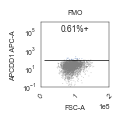

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_Fully unstained.fcs
Processing... fcs_files/ALS_250513_KOLF_regional_spec/Fully stained cVM_KL10.fcs


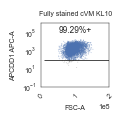

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Fully stained cVM_KL11.fcs


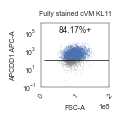

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Fully stained cVM_NKN134.fcs


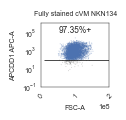

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_BH35.fcs


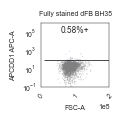

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_BH36.fcs


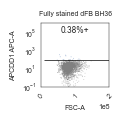

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_BH37.fcs


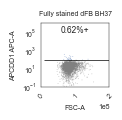

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_TT6.fcs


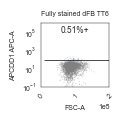

Processing... fcs_files/ALS_250513_KOLF_regional_spec/Fully stained dFB_louise.fcs


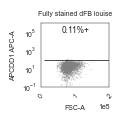

In [ ]:
samples_skip = ['Compensation', 'FMO DAPI']
strings_keep = ['FMO',
                'Fully stained', 'unstained',
                'cVM', 'dFB',
                'KL10', 'KL11', 'NKN134',
                'BH35', 'BH36', 'BH37', 'louise', 'TT6']


custom_theme_5pt()


def plot_density_scatter(data, x_channel, y_channel, xlabel, ylabel, xlim, ylim, yscale='linear'):
    scatter_x = data[:, data.channels.index(x_channel)].astype('<f8')
    scatter_y = data[:, data.channels.index(y_channel)].astype('<f8')

    xy = np.vstack([scatter_x, scatter_y])
    z = gaussian_kde(xy)(xy)
    norm = Normalize(vmin=z.min(), vmax=z.max())
    colors = opaque_bilbao_cmap(norm(z))

    plt.figure(figsize=(2, 2))
    plt.scatter(scatter_x, scatter_y, c=colors, s=0.01, label='Events')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(xlim)
    plt.ylim(ylim)
    if yscale == 'log':
        plt.yscale('log')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def process_files(imported_files):
    #loop over folders and files
    for folder, files in imported_files.items():
        for filename, s in files.items():
            # Skip files with unwanted strings
            if any(sample in filename for sample in samples_skip):
                continue

            print(f"Processing... {filename}")
            
            #clean the filename title.
            title_parts = [string for string in strings_keep if string in filename]
            title = ' '.join(title_parts)
            # title = title.replace('subopt', 'cVM')

            g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(1.3e5, 0.6e5), a=1e5, b=0.5e5, theta=40/180.*np.pi)
            g2 = FlowCal.gate.ellipse(g1, channels=['FSC-A', 'FSC-H'], center=(0.8e5, 0.8e5), a=1e5, b=2e4, theta=40/180.*np.pi)
            g3 = FlowCal.gate.density2d(g2, channels=['SSC-H', 'SSC-W'], gate_fraction=0.97) 
            g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=4e2)

            fluorophores = ['APC']
            fluorophore_mapping = {
                'APC': 'APC-A'
            }
            antibody_mapping = {
                'APC': 'APCDD1 APC-A',
            }
                
            #limits
            xlim_vals = (0, 2e5)
            ylim_vals = (1e-1, 1e6)
            hline_range = (1e4, 3e5)
    

            #loop through fluorophores for files
            for fluorophore, channel in fluorophore_mapping.items():
                if "Fully stained" in filename:
                    #for fully stained samples, use the base fluorophore key
                    fluor_key = fluorophore
                    fluor_title = antibody_mapping[fluorophore]

                else:
                    #fmo-specific conditions
                    if fluorophore == 'APC' and ('APCDD1' in filename or 'FMO APCDD1' in filename):
                        fluor_key = 'APC'
                        fluor_title = 'APCDD1 APC-A'
                    else:
                        print(f"Warning: No antibody identifier found in {filename}. Skipping channel.")
                        continue


                fluorophore_data = g4[:, g4.channels.index(channel)].astype('<f8')
                
                #retrieve gating cutoff
                cutoff = std_cutoffs_3[folder].get(fluor_key, None)
                if cutoff is None:
                    print(f"No cutoff available for {fluor_key} in folder: {folder}")
                    print(f"Available keys in cutoffs_mixed[{folder}]: {std_cutoffs_3[folder].keys()}")
                    continue

                #apply gating
                gated_mask = fluorophore_data > cutoff
                gated_data = fluorophore_data[gated_mask]

                if len(gated_data) == 0:
                    print(f"No gated data for {fluor_key} in {filename}.")
                    continue
                #calculate the percentage of gated events
                gated_percentage = len(gated_data) / len(fluorophore_data) * 100

                #prepare scatter plot data
                scatter_x = g4[:, g4.channels.index('FSC-A')].astype('<f8')
                scatter_y = fluorophore_data  # same as g4 channel data
                
                #sample 4000 events
                scatter_x = scatter_x[:4000]
                scatter_y = scatter_y[:4000]
                #color events based on cutoff
                colors = np.where(scatter_y >= cutoff, '#4C72B0', 'gray')

                #create plot
                plt.figure(figsize=(1.2, 1.2))
                plt.scatter(scatter_x, scatter_y, c=colors, s=0.5, alpha=0.4, linewidths=0)
                # Add horizontal line at the cutoff
                plt.hlines(y=cutoff, xmin=hline_range[0], xmax=hline_range[1],
                            colors='black', linestyles='-', linewidth=0.5)
                
                #customize 
                plt.title(f"{title}")
                plt.text(1e5, 2e5, f"{gated_percentage:.2f}%+",
                            fontsize=6, ha='center', va='center',
                            bbox=dict(facecolor='none', edgecolor='none'))
                plt.xlabel('FSC-A')
                plt.ylabel(fluor_title)
                plt.xlim(xlim_vals)
                plt.ylim(ylim_vals)
                plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                plt.yscale('log')
                plt.xticks(rotation=45, ha='center')                
                plt.tight_layout()
                
                #save
                output_dir = os.path.dirname(f"facs_plots/{filename}_{fluor_key}.pdf")
                os.makedirs(output_dir, exist_ok=True)
                plt.savefig(f"facs_plots/{filename}_{fluor_key}.pdf", dpi=150)
                plt.show()

#build the imported_files dict as before
imported_files = {}
for folder in sorted_files:
    imported_files[folder] = {}
    for filename in sorted_files[folder]:
        try:
            fcs_data = FlowCal.io.FCSData(filename)
            imported_files[folder][filename] = fcs_data
        except ValueError as e:
            print(f"Error reading file {filename}: {e}")

#process files
process_files(imported_files)

# Process data to generate table

In [ ]:
todays_date = datetime.datetime.now().strftime('%Y%m%d')
samples_skip = ['Compensation', 'FMO DAPI']


# create an empty list
data = []

#iterate over the imported files and gate them
#count = 0
for folder, files in imported_files.items():
    for filename, s in files.items():

        #skip specific samples
        if any(sample in filename for sample in samples_skip): #exclude compensation ctrls and abs
            #print(f"Skipping file {filename} due to sample removal criteria.")
            continue
        #print(f"Processing file {filename}")
        #print(f"Available channels: {s.channels}")

        #limit the number of files to process
        #count += 1 
        #if count >= 5:
            #break

        try:
            g1 = FlowCal.gate.ellipse(s, channels=['FSC-A', 'SSC-A'], center=(1.3e5, 0.6e5), a=1e5, b=0.5e5, theta=40/180.*np.pi)
            g2 = FlowCal.gate.ellipse(g1, channels=['FSC-A', 'FSC-H'], center=(0.8e5, 0.8e5), a=1e5, b=2e4, theta=40/180.*np.pi)
            g3 = FlowCal.gate.density2d(g2, channels=['SSC-H', 'SSC-W'], gate_fraction=0.97) 
            g4 = FlowCal.gate.high_low(g3, channels=['DAPI-A'], high=4e2)


            #count the number of events in each gate
            num_events = g1.shape[0]
            ssc_gate_events = g3.shape[0]
            live_gate_events = g4.shape[0]
            
            #fluo gates
            #apcdd1-apc
            g5_3sd = FlowCal.gate.high_low(g4, channels=['APC-A'], low=std_cutoffs_3[folder]['APC']) 
            g5_3sd_mean = np.mean(g5_3sd[:, 'APC-A'])
            g5_3sd_gate_events = g5_3sd.shape[0]

            g5_8sd = FlowCal.gate.high_low(g4, channels=['APC-A'], low=std_cutoffs_8[folder]['APC'])
            g5_8sd_mean = np.mean(g5_8sd[:, 'APC-A'])
            g5_8sd_gate_events = g5_8sd.shape[0]


        
            #calculate mean fluorescence intensity
            channels = ['APC-A']
            means = {}
            for channel in channels:
                if channel in g4.channels:
                    means[channel] = np.mean(g4[:, channel])
                else:
                    print(f"Channel {channel} not found in file {filename}. Setting mean to NaN.")
                    means[channel] = np.nan

            # append to df
            data.append({'filename': filename,

                        #gate events 
                        'num_events': num_events,
                        'ssc_gate_events': ssc_gate_events,
                        'live_gate_events': live_gate_events,
                        
                        #mean+3sd
                        '3sd_mfi': g5_3sd_mean,
                        '3sd_per_pos': (g5_3sd_gate_events / live_gate_events) * 100, #pct> 3sd cutoff
                        
                        #mean+8sd
                        '8sd_mfi': g5_8sd_mean,
                        '8sd_per_pos': (g5_8sd_gate_events / live_gate_events) * 100, #pct> 8sd cutoff
                        
                        #mean mfi
                        'mfi': means['APC-A'],

                        'folder': folder})
        
        
        except ValueError as e:
            print(f"Error processing {filename}: {e}")
            
#create, view, and save the dataframe
regional_spec_kolf = pd.DataFrame(data)
regional_spec_kolf.to_csv(f"output/flow py regional spec kolf {todays_date}.csv", index=False)
regional_spec_kolf.head()

/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3462: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


,filename,num_events,ssc_gate_events,live_gate_events,3sd_mfi,3sd_per_pos,8sd_mfi,8sd_per_pos,mfi,folder
0,fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_...,11264,10307,9376,111.546661,0.607935,292.736755,0.010666,13.396008,ALS_250513_KOLF_regional_spec
1,fcs_files/ALS_250513_KOLF_regional_spec/Ctrls_...,5845,5229,5095,113.587204,0.785083,269.923645,0.039254,14.465322,ALS_250513_KOLF_regional_spec
2,fcs_files/ALS_250513_KOLF_regional_spec/Fully ...,6015,5023,4623,2144.450439,99.286178,2233.549072,95.046507,2129.551270,ALS_250513_KOLF_regional_spec
3,fcs_files/ALS_250513_KOLF_regional_spec/Fully ...,5647,5115,4762,563.246887,84.166317,725.046936,60.856783,481.892700,ALS_250513_KOLF_regional_spec
4,fcs_files/ALS_250513_KOLF_regional_spec/Fully ...,11319,10110,9232,1455.446289,97.346187,1622.284912,86.330156,1418.301392,ALS_250513_KOLF_regional_spec


# Cleaning

In [ ]:
todays_date = datetime.datetime.now().strftime('%Y%m%d')
regional_spec_kolf = pd.read_csv(f"output/flow py regional spec kolf {todays_date}.csv")

#define strings to extract region and batch info from filename
region_strings = ['cVM', 'dFB']
batch_strings = ['KL10', 'KL11', 'NKN134', 'BH35', 'BH36', 'BH37', 'louise', 'TT6']

#create a new region column based on the presence of region_strings
regional_spec_kolf['region'] = regional_spec_kolf['filename'].apply(
    lambda x: next((region for region in region_strings if region in x), None)
)
#create a new batch column based on the presence of batch_strings
regional_spec_kolf['batch'] = regional_spec_kolf['filename'].apply(
    lambda x: next((batch for batch in batch_strings if batch in x), None)
)

#remove the string fcs_files/ALS_250513_KOLF_regional_spec/ from the filename
regional_spec_kolf['filename'] = regional_spec_kolf['filename'].str.replace('fcs_files/ALS_250513_KOLF_regional_spec/', '', regex=False)

#filter out the unstained
regional_spec_kolf = regional_spec_kolf[~regional_spec_kolf['filename'].str.contains('unstained')]

#calculate the pct live cells
regional_spec_kolf['pct_live'] = (regional_spec_kolf['live_gate_events'] / regional_spec_kolf['ssc_gate_events']) * 100

#drop the columns num_events, ssc_gate_events, live_gate_events, apc_gate_events
regional_spec_kolf = regional_spec_kolf.drop(columns=['num_events', 'ssc_gate_events', 'live_gate_events'])

#extract the type of sample from the filename
def extract_sample_type(filename):
    if 'FMO' in filename:
        return 'fmo'
    elif 'Fully stained' in filename:
        return 'fully_stained'
    else:
        return 'Unknown'

regional_spec_kolf['sample_type'] = regional_spec_kolf['filename'].apply(extract_sample_type)

#drop filename column
regional_spec_kolf = regional_spec_kolf.drop(columns=['filename'])

#remove string '_KOLF_regional_spec' from folder name
regional_spec_kolf['folder'] = regional_spec_kolf['folder'].str.replace('_KOLF_regional_spec', '', regex=False)

#replace 'None' in batch and region with 'mixed'
regional_spec_kolf['batch'] = regional_spec_kolf['batch'].replace({None: 'mixed'})
regional_spec_kolf['region'] = regional_spec_kolf['region'].replace({None: 'mixed'})

#create a new column 'marker' that contains the string 'apc'
regional_spec_kolf['marker'] = 'apc'

#save the dataframe
regional_spec_kolf.to_csv(f"output/flow py regional spec kolf cleaned {todays_date}.csv", index=False)
regional_spec_kolf.head(10)

,3sd_mfi,3sd_per_pos,8sd_mfi,8sd_per_pos,mfi,folder,region,batch,pct_live,sample_type,marker
0,111.546660,0.607935,292.73676,0.010666,13.396008,ALS_250513,mixed,mixed,90.967304,fmo,apc
2,2144.450400,99.286178,2233.54900,95.046507,2129.551300,ALS_250513,cVM,KL10,92.036631,fully_stained,apc
3,563.246900,84.166317,725.04694,60.856783,481.892700,ALS_250513,cVM,KL11,93.098729,fully_stained,apc
4,1455.446300,97.346187,1622.28490,86.330156,1418.301400,ALS_250513,cVM,NKN134,91.315529,fully_stained,apc
5,156.578810,0.584795,431.40780,0.080661,11.501248,ALS_250513,dFB,BH35,96.422322,fully_stained,apc
6,142.536040,0.380076,291.19310,0.060012,9.737119,ALS_250513,dFB,BH36,94.624267,fully_stained,apc
7,144.306080,0.616333,270.78687,0.123267,10.733395,ALS_250513,dFB,BH37,93.193567,fully_stained,apc
8,113.830130,0.514099,NaN,0.000000,9.805803,ALS_250513,dFB,TT6,96.715383,fully_stained,apc
9,96.887245,0.114220,NaN,0.000000,11.677467,ALS_250513,dFB,louise,93.988191,fully_stained,apc


# Plot

In [16]:
#pivot all numerical columns to long format
regional_spec_kolf_long = regional_spec_kolf.melt(id_vars=['folder', 'region', 'batch', 'sample_type'],
                                                  value_vars=['3sd_mfi', 'mfi', 'pct_live', '3sd_per_pos'],
                                                  var_name='metric', value_name='value')

regional_spec_kolf_long.head()

,folder,region,batch,sample_type,metric,value
0,ALS_250513,mixed,mixed,fmo,3sd_mfi,111.54666
1,ALS_250513,cVM,KL10,fully_stained,3sd_mfi,2144.45040
2,ALS_250513,cVM,KL11,fully_stained,3sd_mfi,563.24690
3,ALS_250513,cVM,NKN134,fully_stained,3sd_mfi,1455.44630
4,ALS_250513,dFB,BH35,fully_stained,3sd_mfi,156.57881


In [17]:
print(regional_spec_kolf_long['metric'].unique())
regional_spec_kolf_long.tail()

['3sd_mfi' 'mfi' 'pct_live' '3sd_per_pos']


,folder,region,batch,sample_type,metric,value
31,ALS_250513,dFB,BH35,fully_stained,3sd_per_pos,0.584795
32,ALS_250513,dFB,BH36,fully_stained,3sd_per_pos,0.380076
33,ALS_250513,dFB,BH37,fully_stained,3sd_per_pos,0.616333
34,ALS_250513,dFB,TT6,fully_stained,3sd_per_pos,0.514099
35,ALS_250513,dFB,louise,fully_stained,3sd_per_pos,0.114220


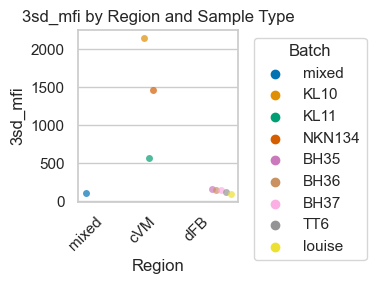

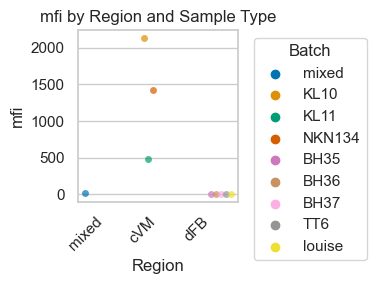

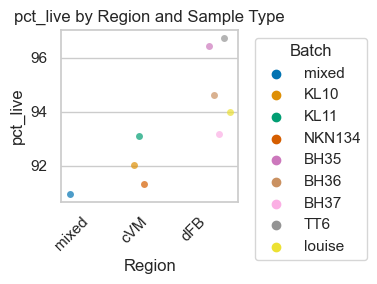

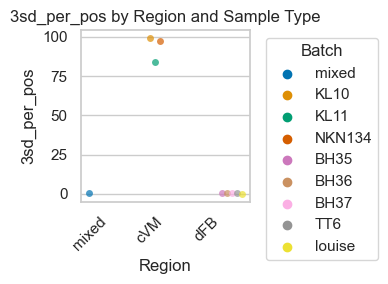

In [ ]:
custom_theme_6pt()

#plot the long data as a dotplots per metric (region on the x axis and value on the y axis)
def plot_dotplot(data, metric, title):
    plt.figure(figsize=(4, 3))
    sns.set(style="whitegrid")
    sns.set_palette("colorblind")
    sns.stripplot(x='region', y='value', hue='batch', 
                  data=data[data['metric'] == metric], dodge=True, alpha=0.7)
    plt.title(title)
    plt.xlabel('Region')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Batch', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#specify the metrics to plot
metrics = ['3sd_mfi', 'mfi', 'pct_live', '3sd_per_pos']

for metric in metrics:
    plot_dotplot(regional_spec_kolf_long, metric, f"{metric} by Region and Sample Type")
#save the plots to a pdf file
#output_dir = "output/plots"
#os.makedirs(output_dir, exist_ok=True)